In [6]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn imbalanced-learn gensim
!pip install --quiet gspread gspread_pandas --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from gensim.models import Word2Vec

# Downloading required NLTK data
def download_nltk_resources():
    resources = ['punkt', 'stopwords', 'wordnet', 'omw-1.4']
    for res in resources:
        try:
            nltk.data.find(f'tokenizers/{res}' if res == 'punkt' else f'corpora/{res}')
        except LookupError:
            nltk.download(res, quiet=True)

download_nltk_resources()


# NLP Emotion Classification Pipeline
This notebook implements a comprehensive Natural Language Processing text classification pipeline. It covers preprocessing, dataset balancing, embeddings (TF-IDF, Count Vectorizer, Word2Vec), and automatic machine learning model selection and evaluation.


## 1. Data Loading & Preprocessing
Here we load the dataset, identify the text and label columns, drop any missing values, and apply text preprocessing techniques: Tokenization, Stopword Removal, Stemming, and Lemmatization.


In [19]:
!python -m nltk.downloader punkt punkt_tab stopwords wordnet


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [20]:
from google.colab import files
import pandas as pd

# Step 1: Upload file from PC
uploaded = files.upload()  # Click "Choose Files" and select your Excel

# Step 2: Load Excel file into pandas
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)


# Identify text and label columns and drop NaN values
df = df.dropna(subset=['Tweets', 'Level 2'])

X_raw = df['Tweets'].astype(str)
y_raw = df['Level 2']

# Preprocessing tools initialization
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # a. Tokenization and lowercasing
    try:
        tokens = word_tokenize(text.lower())
    except LookupError:
        nltk.download('punkt')
        tokens = word_tokenize(text.lower())

    # Keep only alphabetical tokens
    tokens = [word for word in tokens if word.isalpha()]

    # b. Stopword Removal
    tokens = [word for word in tokens if word not in stop_words]

    # c. Stemming
    tokens_stemmed = [stemmer.stem(word) for word in tokens]

    # d. Lemmatization
    tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens_stemmed]

    # Rejoin into string
    return " ".join(tokens_lemmatized)

print("Applying text preprocessing to all data...")
df['Clean_Tweets'] = X_raw.apply(preprocess_text)
X_clean = df['Clean_Tweets']


Saving RU-EN-Emotion Dataset.xlsx to RU-EN-Emotion Dataset (2).xlsx
Applying text preprocessing to all data...


## 2. Class Distribution Analysis
Visualizing the distribution of emotion classes in the dataset before balancing.


Class counts before balancing:
Level 2
Neutral     11629
Happy        3720
Anger        3487
Sad           712
Fear          227
Surprise      224
Name: count, dtype: int64


/tmp/ipykernel_6859/2648395431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_raw, order=y_raw.value_counts().index, palette='viridis')


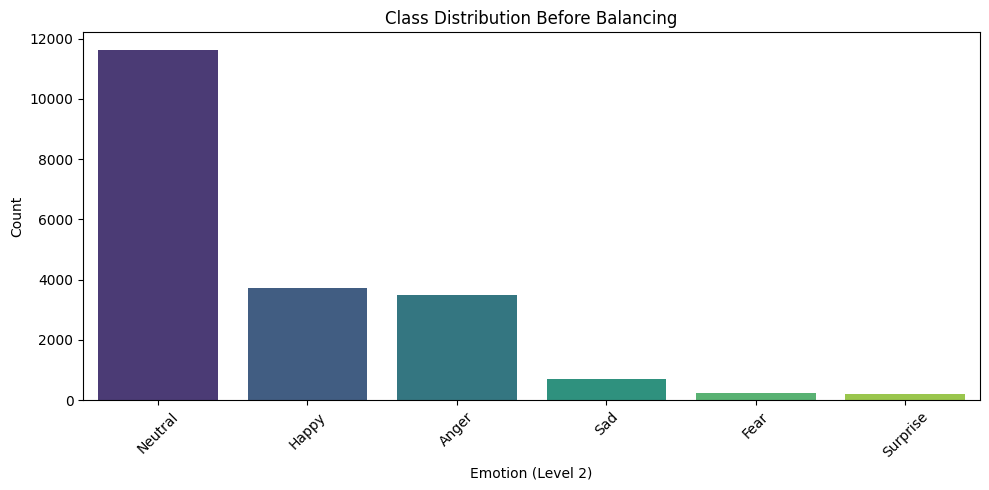

In [11]:
print("Class counts before balancing:")
print(y_raw.value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x=y_raw, order=y_raw.value_counts().index, palette='viridis')
plt.title('Class Distribution Before Balancing')
plt.xlabel('Emotion (Level 2)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Class Balancing
Since text can't be directly balanced using SMOTE without numerical representation, we use `RandomOverSampler` on the textual data directly to balance class distributions.


Class counts AFTER balancing:
Level 2
Anger       11629
Happy       11629
Fear        11629
Surprise    11629
Sad         11629
Neutral     11629
Name: count, dtype: int64


/tmp/ipykernel_6859/2536693696.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_balanced, order=y_balanced.value_counts().index, palette='viridis')


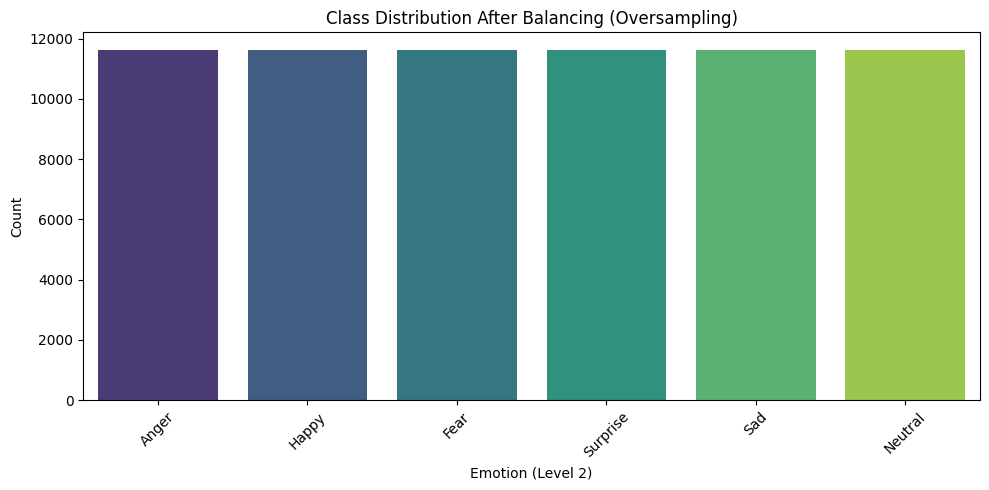

In [21]:
ros = RandomOverSampler(random_state=42)

# Reshape necessary for sklearn API
X_clean_reshaped = X_clean.values.reshape(-1, 1)
X_balanced_reshaped, y_balanced = ros.fit_resample(X_clean_reshaped, y_raw)

# Flatten back to 1D array/series
X_balanced = pd.Series(X_balanced_reshaped.flatten())

print("Class counts AFTER balancing:")
print(y_balanced.value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x=y_balanced, order=y_balanced.value_counts().index, palette='viridis')
plt.title('Class Distribution After Balancing (Oversampling)')
plt.xlabel('Emotion (Level 2)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Vectorization Techniques
Applying three distinct text vectorization methods: Count Vectorization, Term Frequency-Inverse Document Frequency (TF-IDF), and Word2Vec.


In [22]:
# a. Count Vectorization
print("Fitting CountVectorizer...")
count_vec = CountVectorizer(max_features=5000)
X_count = count_vec.fit_transform(X_balanced)

# b. TF-IDF Vectorization
print("Fitting TfidfVectorizer...")
tfidf_vec = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vec.fit_transform(X_balanced)

# c. Word2Vec Vectorization
print("Training Word2Vec embeddings...")
tokenized_sentences = [text.split() for text in X_balanced]

w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_avg_word2vec(tokens, w2v_model, vector_size):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print("Applying Word2Vec averaging to each document...")
X_w2v = np.array([get_avg_word2vec(tokens, w2v_model, 100) for tokens in tokenized_sentences])


Fitting CountVectorizer...
Fitting TfidfVectorizer...
Training Word2Vec embeddings...
Applying Word2Vec averaging to each document...


## 5. Train-Test Split
Splitting all three vectorization arrays into training and testing sets with a consistent random state so index splits align identically across experiments.


In [24]:
X_train_c, X_test_c, y_train, y_test = train_test_split(X_count, y_balanced, test_size=0.2, random_state=42)
X_train_t, X_test_t, _, _ = train_test_split(X_tfidf, y_balanced, test_size=0.2, random_state=42)
X_train_w, X_test_w, _, _ = train_test_split(X_w2v, y_balanced, test_size=0.2, random_state=42)

print(f"Training set: {X_train_c.shape[0]} samples")
print(f"Testing set : {X_test_c.shape[0]} samples")


Training set: 55819 samples
Testing set : 13955 samples


## 6. Model Selection Pipeline
Evaluating a wide array of machine learning models rapidly against the TF-IDF feature set to identify the top performing models.


In [25]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVC (Linear)': SVC(kernel='linear', random_state=42)
}

automated_results = {}
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_t, y_train)
    y_pred_temp = clf.predict(X_test_t)
    acc = accuracy_score(y_test, y_pred_temp)
    automated_results[name] = acc
    print(f"  {name} Accuracy: {acc:.4f}")

# Sort and identify top-performing models
sorted_models = sorted(automated_results.items(), key=lambda item: item[1], reverse=True)
print("\nAll Estimators Ranked by Accuracy (on TF-IDF):")
result_df = pd.DataFrame(sorted_models, columns=['Model', 'Accuracy'])
display(result_df)

# Select top 3 models for deeper analysis
top_3_names = [model[0] for model in sorted_models[:3]]
print(f"\nSelecting top 3 models for further experiments: {top_3_names}")

# Retrieve the actual model objects
sel_classifiers = {name: classifiers[name] for name in top_3_names}


Training Logistic Regression...
  Logistic Regression Accuracy: 0.8645
Training Random Forest...
  Random Forest Accuracy: 0.9463
Training Decision Tree...
  Decision Tree Accuracy: 0.9142
Training Multinomial NB...
  Multinomial NB Accuracy: 0.7939
Training KNN...
  KNN Accuracy: 0.8830
Training AdaBoost...
  AdaBoost Accuracy: 0.3430
Training SVC (Linear)...
  SVC (Linear) Accuracy: 0.8770

All Estimators Ranked by Accuracy (on TF-IDF):


,Model,Accuracy
0,Random Forest,0.946327
1,Decision Tree,0.914153
2,KNN,0.882981
3,SVC (Linear),0.876962
4,Logistic Regression,0.864493
5,Multinomial NB,0.793909
6,AdaBoost,0.343031



Selecting top 3 models for further experiments: ['Random Forest', 'Decision Tree', 'KNN']


## 7. Comprehensive Experiments and Evaluation
Now we perform full combinations by evaluating the top 3 models on each of the 3 vectorization techniques, yielding 9 complete experiments.


In [26]:
vectorizations = {
    'CountVectorization': (X_train_c, X_test_c),
    'TF-IDF': (X_train_t, X_test_t),
    'Word2Vec': (X_train_w, X_test_w)
}

experiment_results = []
confusion_matrices = {}

for vec_name, (X_tr, X_te) in vectorizations.items():
    for clf_name, clf_obj in sel_classifiers.items():
        exp_name = f"{clf_name} + {vec_name}"
        print(f"\n>> Experiment: {exp_name}")

        # MultinomialNB naturally strictly requires non-negative values.
        # Word2Vec produces negative continuous variables, so we softly bypass it if needed.
        if isinstance(clf_obj, MultinomialNB) and vec_name == 'Word2Vec':
            print("  Skipping Multinomial NB with Word2Vec due to negative input values.")
            continue

        clf_obj.fit(X_tr, y_train)
        y_pred = clf_obj.predict(X_te)

        # Performance Evaluation Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        experiment_results.append({
            'Model': clf_name,
            'Vectorization': vec_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        print(f"  Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

        # Extract Confusion Matrix for final visualization
        cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
        confusion_matrices[exp_name] = (cm, np.unique(y_test))



>> Experiment: Random Forest + CountVectorization
  Accuracy:  0.9503 | Precision: 0.9504 | Recall: 0.9503 | F1-Score: 0.9495

>> Experiment: Decision Tree + CountVectorization
  Accuracy:  0.9158 | Precision: 0.9174 | Recall: 0.9158 | F1-Score: 0.9102

>> Experiment: KNN + CountVectorization
  Accuracy:  0.8737 | Precision: 0.8707 | Recall: 0.8737 | F1-Score: 0.8684

>> Experiment: Random Forest + TF-IDF
  Accuracy:  0.9463 | Precision: 0.9463 | Recall: 0.9463 | F1-Score: 0.9453

>> Experiment: Decision Tree + TF-IDF
  Accuracy:  0.9142 | Precision: 0.9161 | Recall: 0.9142 | F1-Score: 0.9083

>> Experiment: KNN + TF-IDF
  Accuracy:  0.8870 | Precision: 0.8856 | Recall: 0.8870 | F1-Score: 0.8851

>> Experiment: Random Forest + Word2Vec
  Accuracy:  0.9434 | Precision: 0.9436 | Recall: 0.9434 | F1-Score: 0.9422

>> Experiment: Decision Tree + Word2Vec
  Accuracy:  0.9103 | Precision: 0.9118 | Recall: 0.9103 | F1-Score: 0.9041

>> Experiment: KNN + Word2Vec
  Accuracy:  0.8664 | Precisi

## 8. Final Results and Visualizations
Review the aggregated tabular results of all experiments and visualize classification performance via confusion matrices heatmaps.


FINAL TABLE OF EXPERIMENT RESULTS


,Model,Vectorization,Accuracy,Precision,Recall,F1-Score
0,Random Forest,CountVectorization,0.950269,0.950375,0.950269,0.949473
1,Decision Tree,CountVectorization,0.915801,0.917383,0.915801,0.910182
2,KNN,CountVectorization,0.873665,0.870715,0.873665,0.868439
3,Random Forest,TF-IDF,0.946327,0.946338,0.946327,0.945260
4,Decision Tree,TF-IDF,0.914153,0.916089,0.914153,0.908261
5,KNN,TF-IDF,0.886994,0.885575,0.886994,0.885142
6,Random Forest,Word2Vec,0.943389,0.943586,0.943389,0.942161
7,Decision Tree,Word2Vec,0.910283,0.911827,0.910283,0.904084
8,KNN,Word2Vec,0.866428,0.872676,0.866428,0.853623



Results saved to CSV.


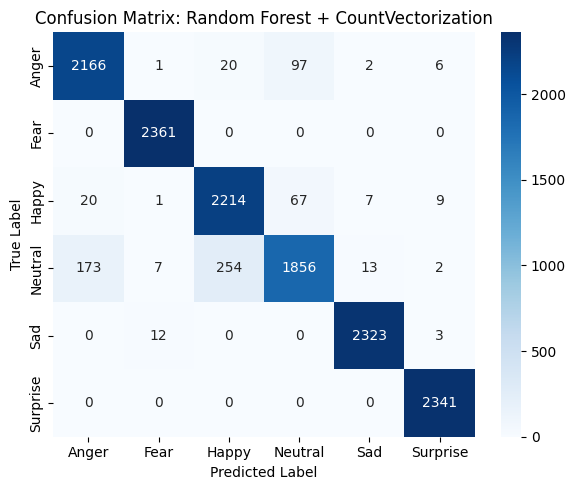

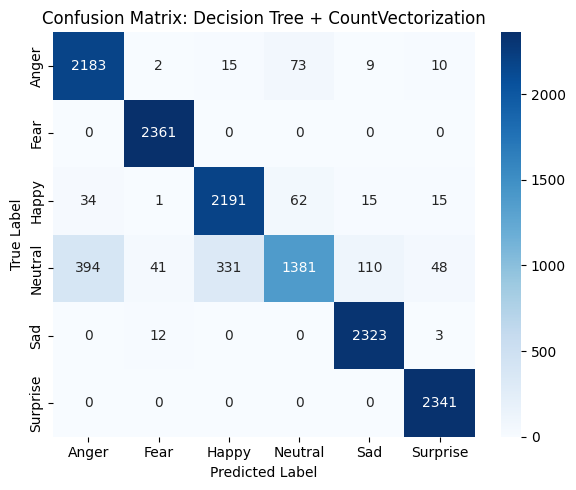

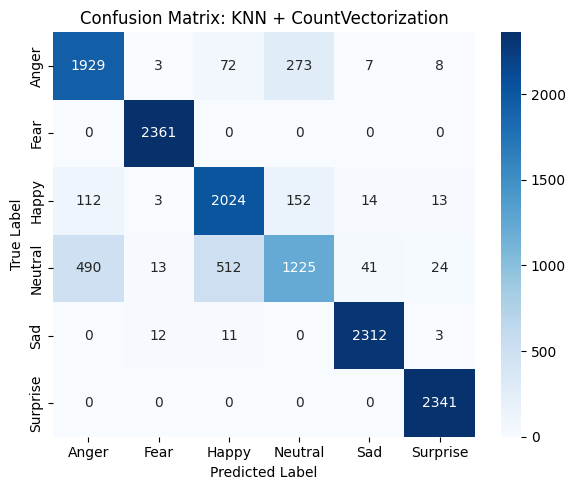

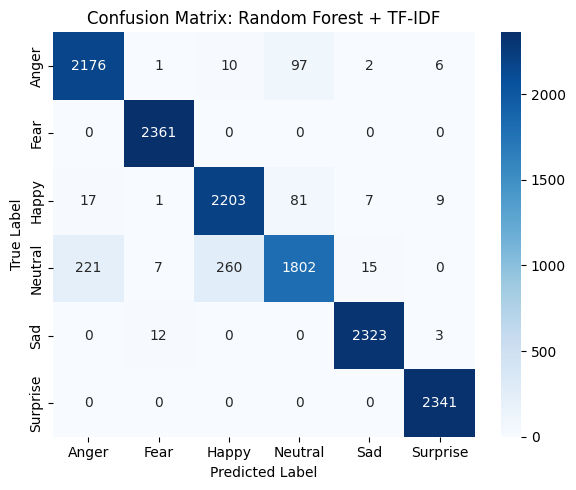

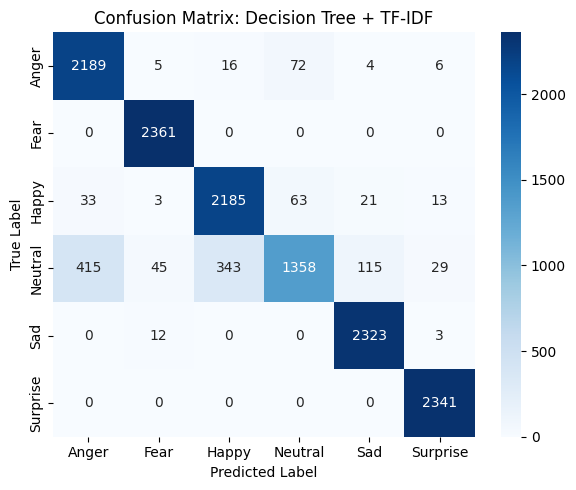

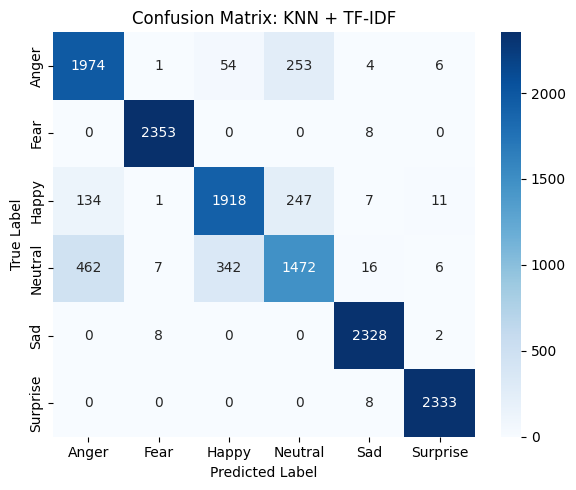

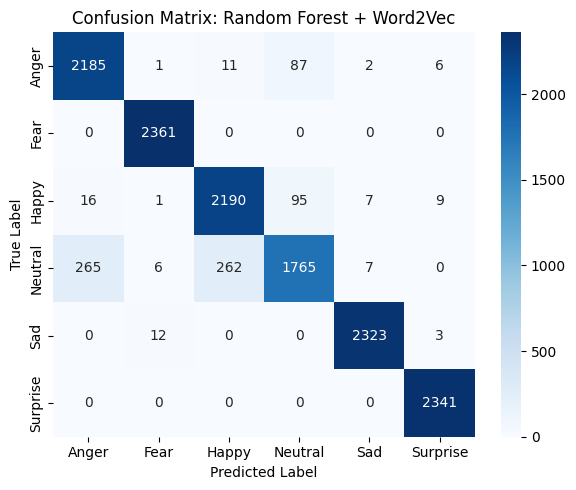

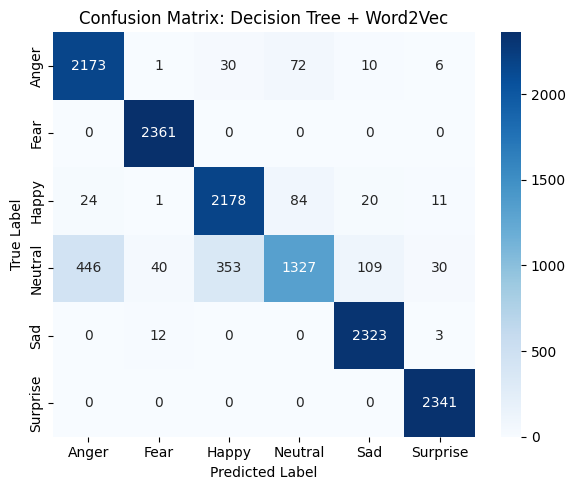

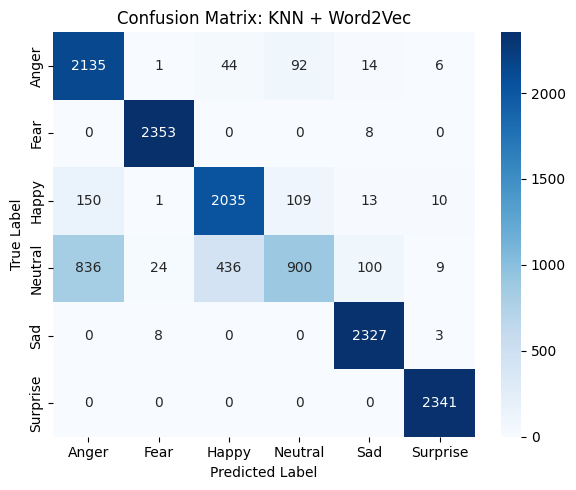

In [27]:
print("========================================================")
print("FINAL TABLE OF EXPERIMENT RESULTS")
print("========================================================")
exp_df = pd.DataFrame(experiment_results)
display(exp_df)

exp_df.to_csv('experiment_results.csv', index=False)
result_df.to_csv('automated_model_selection_results.csv', index=False)
print("\nResults saved to CSV.")

# Confusion Matrix Heatmaps Compilation
for exp_name, (cm, labels) in confusion_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {exp_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
